## Load and Understand the Data

In [1]:
import pandas as pd

df = pd.read_csv("data/california_housing.csv")

print(df.head())

print("\nDataset Shape:")
print(df.shape) #rows and cols 

print("\nColumn Names:")
print(df.columns) #name of the columns

print("\nDataset Information:")
print(df.info()) #summary of the dataset

print("\nMissing Values:")
print(df.isnull().sum())#Checking for Missing Values

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset Shape:
(20640, 9)

Column Names:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       -------

## Create Categorical Groups

In [18]:
#Age Groups
df["AgeGroup"] = pd.cut( #function divides data according to quantiles
    df["HouseAge"],
    bins=[0, 20, 40, float("inf")],
    labels=["New", "Middle-aged", "Old"]
)

The `HouseAge` variable is divided into three categories—New, Middle-aged, and Old—using `pd.cut()` based on predefined age intervals.

In [19]:
#income groups
df["IncomeGroup"] = pd.qcut( #function divides data according to quantiles
    df["MedInc"],
    q=3, #divides the observations into three approximately equal-sized groups.
    labels=["Low", "Medium", "High"]
)

The `MedInc` variable is divided into Low, Medium, and High income groups using `pd.qcut()`, which creates approximately equal-sized groups based on the data distribution.

I used the pd.qcut() function with q=3. This first considers all the income values in the dataset and divides them into three approximately equal-sized groups:

The lowest one-third of income values → Low
The middle one-third → Medium
The highest one-third → High

In [4]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,AgeGroup,IncomeGroup
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,Old,High
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,Middle-aged,High
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,Old,High
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,Old,High
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,Old,Medium



The first five rows are displayed to confirm that the `AgeGroup` and `IncomeGroup` columns were successfully added to the dataset.

## Descriptive Statistics

In [5]:
numerical_columns = df.select_dtypes(include="number").columns

descriptive_stats = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Standard Deviation": df[numerical_columns].std(),
    "IQR": df[numerical_columns].quantile(0.75)
           - df[numerical_columns].quantile(0.25),
    "Skewness": df[numerical_columns].skew(),
    "Kurtosis": df[numerical_columns].kurt()
})

print(descriptive_stats)

                    Mean       Median  Standard Deviation         IQR  \
MedInc          3.870671     3.534800            1.899822    2.179850   
HouseAge       28.639486    29.000000           12.585558   19.000000   
AveRooms        5.429000     5.229129            2.474173    1.611665   
AveBedrms       1.096675     1.048780            0.473911    0.093447   
Population   1425.476744  1166.000000         1132.462122  938.000000   
AveOccup        3.070655     2.818116           10.386050    0.852520   
Latitude       35.631861    34.260000            2.135952    3.780000   
Longitude    -119.569704  -118.490000            2.003532    3.790000   
MedHouseVal     2.068558     1.797000            1.153956    1.451250   

              Skewness      Kurtosis  
MedInc        1.646657      4.952524  
HouseAge      0.060331     -0.800629  
AveRooms     20.697869    879.353264  
AveBedrms    31.316956   1636.711972  
Population    4.935858     73.553116  
AveOccup     97.639561  10651.01063

HouseAge is relatively symmetric
Mean = 28.64
Median = 29
Skewness = 0.06

Since the mean and median are very close and skewness is close to 0, the distribution is approximately symmetric.

A large positive skewness means there are some extremely high values/outliers on the right side.

For example, AveOccup has:
Mean = 3.07
Median = 2.82
Skewness = 97.64 
Kurtosis = 10651.01

 It means that the dataset probably contains some extreme values.

## Visual Exploratory Data Analysis

### Histograms for numerical values

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

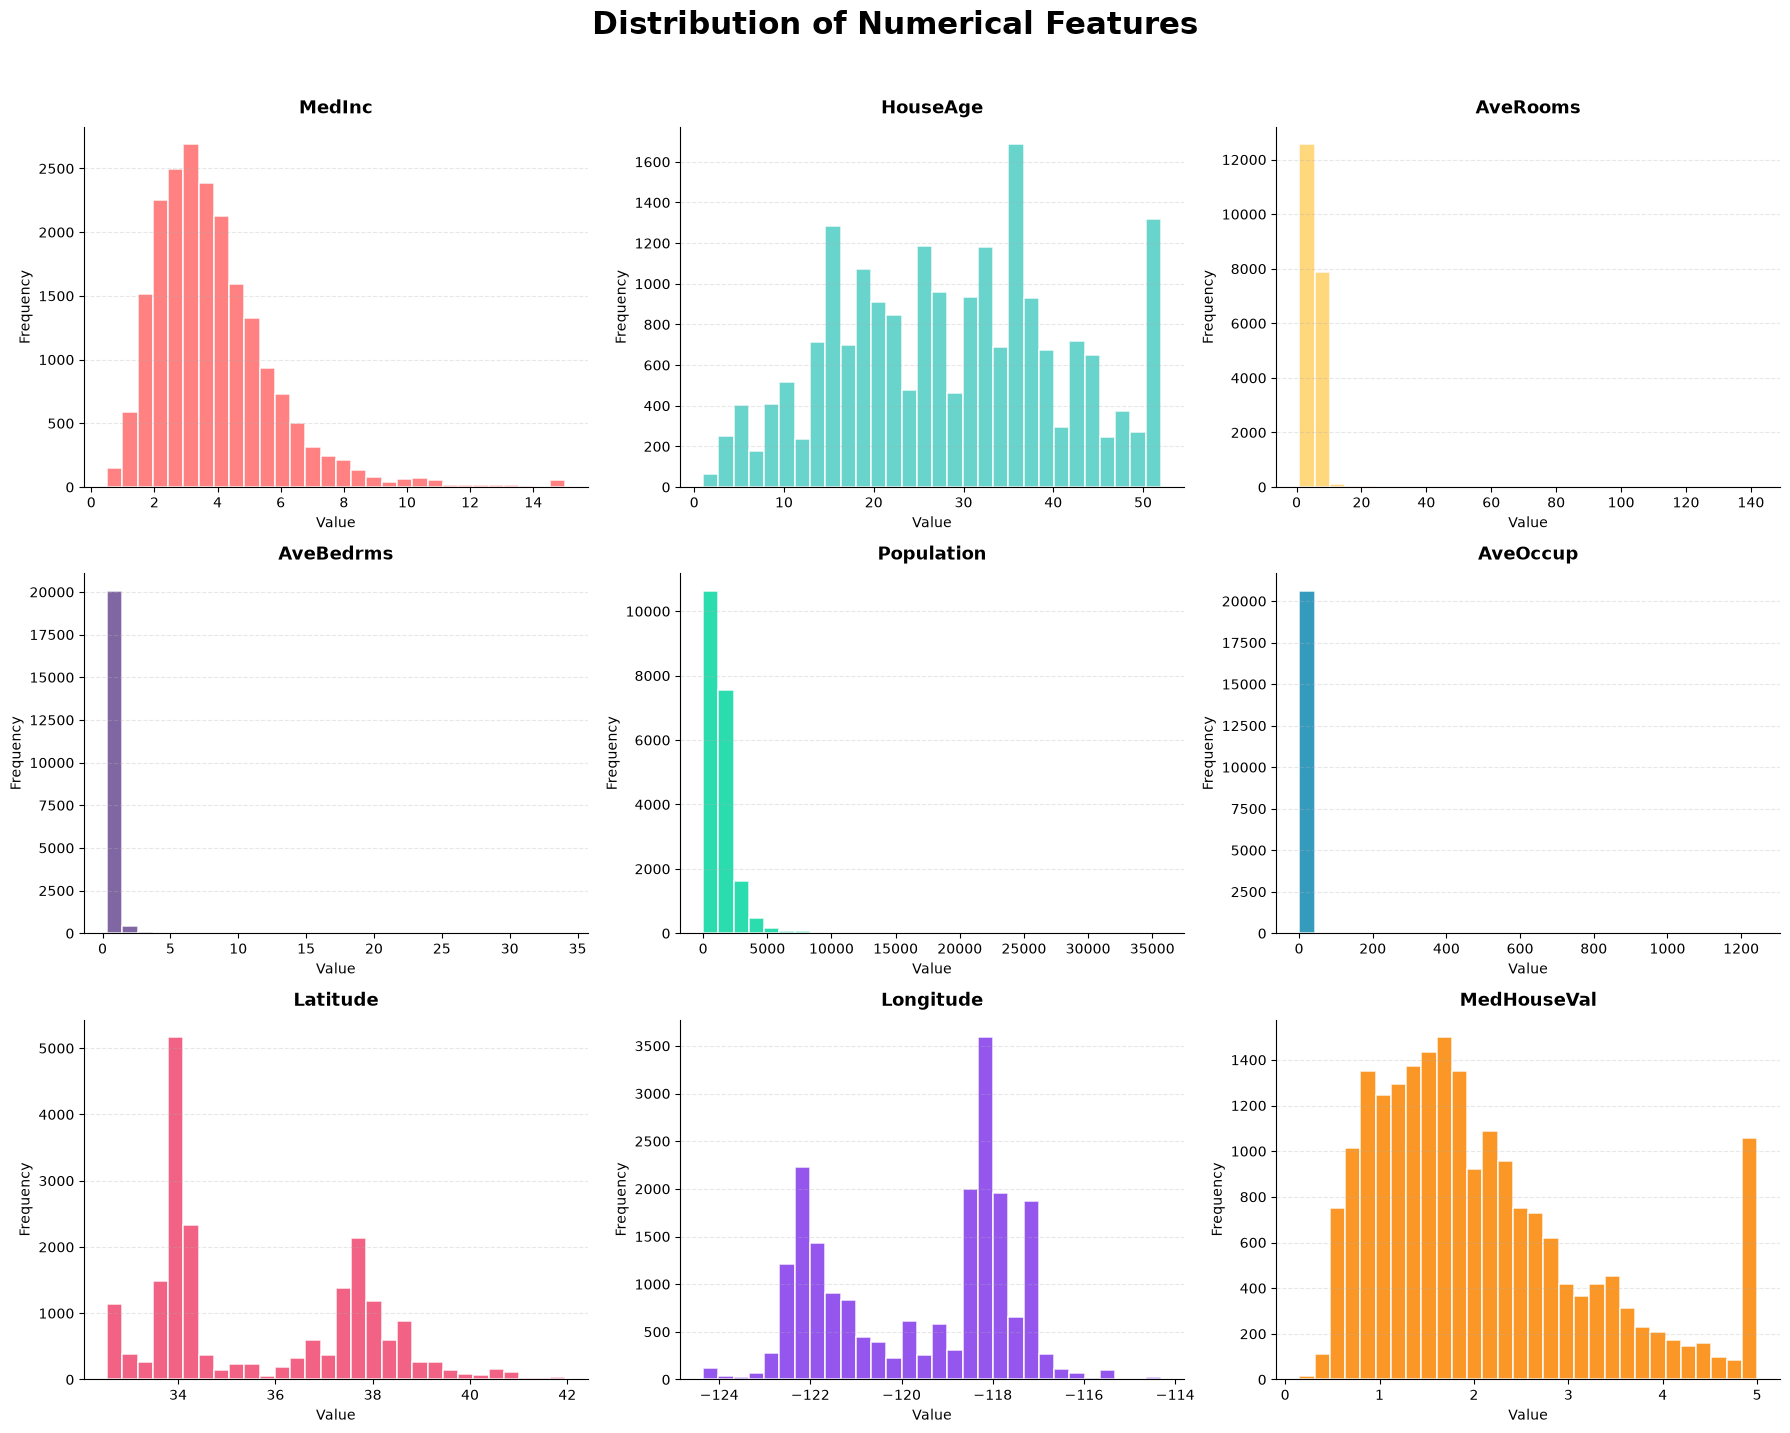

In [7]:
# Histogram for all numerical variables

import matplotlib.pyplot as plt

# Attractive color palette
colors = [
    "#FF6B6B",  # Coral Red
    "#4ECDC4",  # Turquoise
    "#FFD166",  # Yellow
    "#6A4C93",  # Purple
    "#06D6A0",  # Green
    "#118AB2",  # Blue
    "#EF476F",  # Pink
    "#8338EC",  # Violet
    "#FB8500"   # Orange
]

# Create subplot grid
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(18, 14)
)

axes = axes.flatten()

# Plot each numerical column
for i, column in enumerate(numerical_columns):
    
    axes[i].hist(
        df[column].dropna(),
        bins=30,
        color=colors[i % len(colors)],
        edgecolor="white",
        linewidth=1.2,
        alpha=0.85
    )
    
    axes[i].set_title(
        column,
        fontsize=13,
        fontweight="bold",
        pad=10
    )
    
    axes[i].set_xlabel("Value", fontsize=10)
    axes[i].set_ylabel("Frequency", fontsize=10)

    # Grid
    axes[i].grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    # Clean appearance
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

# Remove unused plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Main title
fig.suptitle(
    "Distribution of Numerical Features",
    fontsize=22,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "images/numerical_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Kernel Density Estimation Plots

A smooth, continuous curve that shows the probability distribution of a continuous variables(histogram)

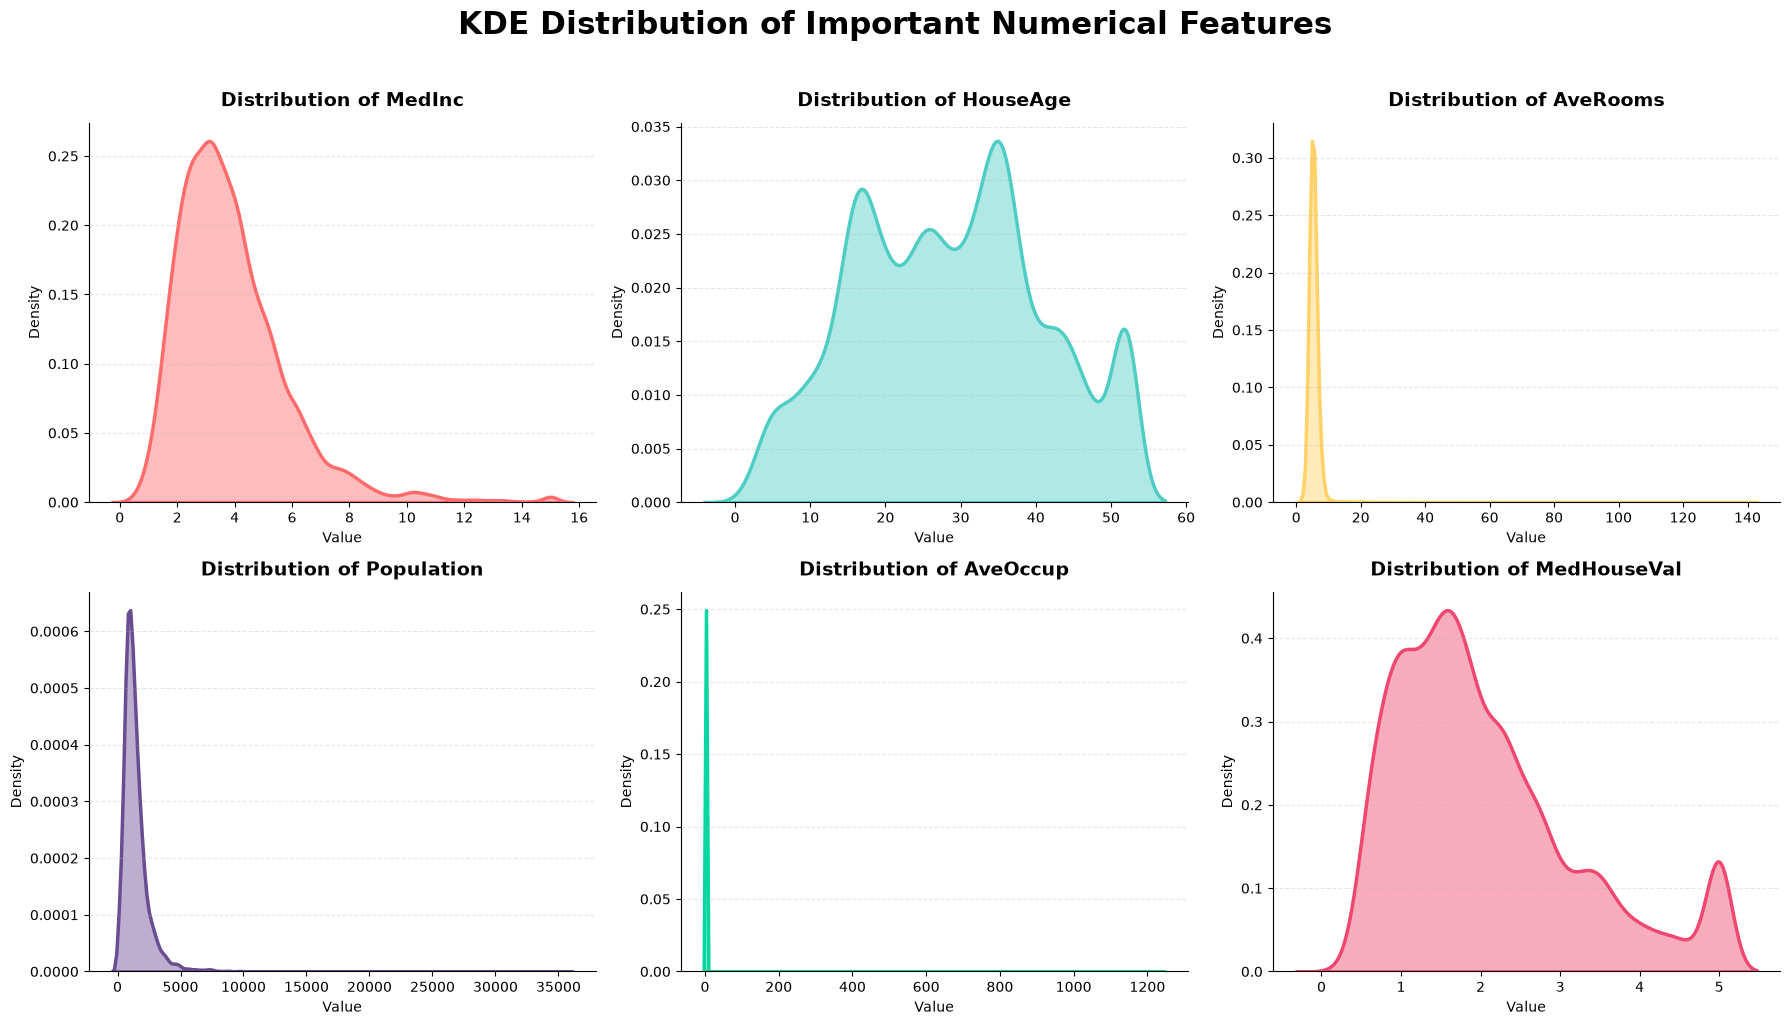

In [8]:
# KDE plots for selected important variables



selected_columns = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "Population",
    "AveOccup",
    "MedHouseVal"
]

# Attractive color palette
colors = [
    "#FF6B6B",  # Coral Red
    "#4ECDC4",  # Turquoise
    "#FFD166",  # Yellow
    "#6A4C93",  # Purple
    "#06D6A0",  # Green
    "#EF476F"   # Pink
]

# Create figure and subplots
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18, 10)
)

axes = axes.flatten()

# Create KDE plot for each variable
for i, column in enumerate(selected_columns):

    sns.kdeplot(
        data=df,
        x=column,
        fill=True,
        color=colors[i],
        linewidth=2.5,
        alpha=0.45,
        ax=axes[i]
    )

    # Title
    axes[i].set_title(
        f"Distribution of {column}",
        fontsize=14,
        fontweight="bold",
        pad=12
    )

    # Labels
    axes[i].set_xlabel("Value", fontsize=10)
    axes[i].set_ylabel("Density", fontsize=10)

    # Grid
    axes[i].grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    # Clean borders
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)


# Main title
fig.suptitle(
    "KDE Distribution of Important Numerical Features",
    fontsize=22,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

# Save high-quality image
plt.savefig(
    "images/kde_plots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Histograms and Kernel Density Estimation (KDE) plots were generated to examine the distribution of numerical variables. The analysis revealed that several variables, including AveRooms, AveBedrms, Population, and AveOccup, exhibit substantial positive skewness. This observation is consistent with the descriptive statistics, particularly the high skewness and kurtosis values.

In contrast, HouseAge showed a relatively symmetric distribution, as indicated by its skewness value close to zero.

### Scatter Plots

Visualizes relationship between two variables.

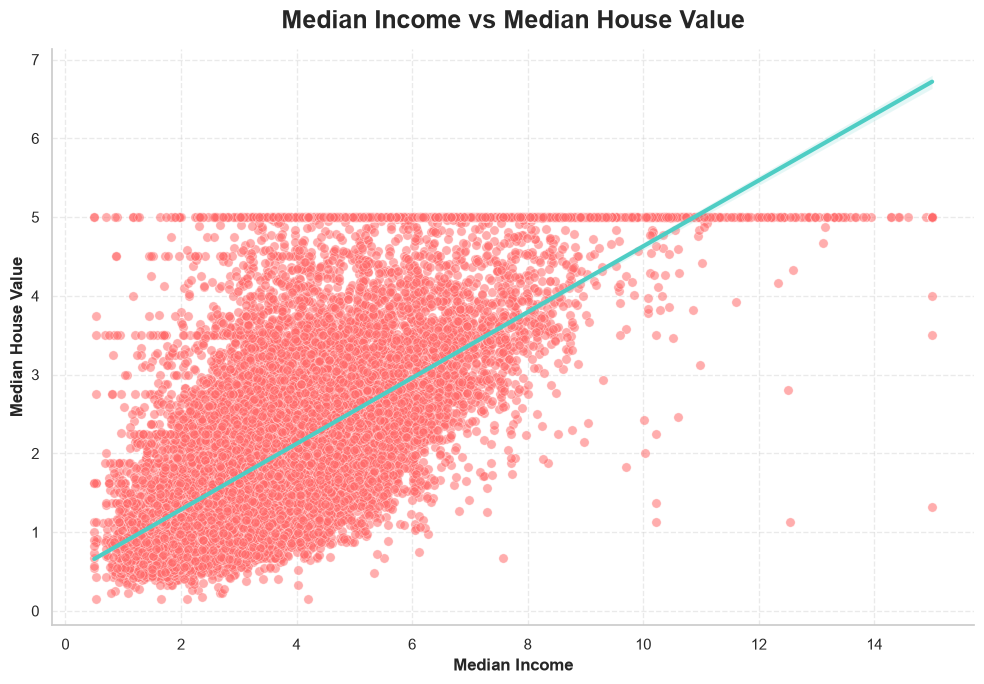

In [9]:

# Set a clean plotting style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 7))

# Scatter plot
sns.scatterplot(
    data=df,
    x="MedInc",
    y="MedHouseVal",
    color="#FF6B6B",       # Attractive coral color
    alpha=0.55,
    s=45,                  # Point size
    edgecolor="white",
    linewidth=0.4
)

# Add regression/trend line
sns.regplot(
    data=df,
    x="MedInc",
    y="MedHouseVal",
    scatter=False,
    color="#4ECDC4",
    line_kws={"linewidth": 3}
)

# Title
plt.title(
    "Median Income vs Median House Value",
    fontsize=18,
    fontweight="bold",
    pad=15
)

# Axis labels
plt.xlabel("Median Income", fontsize=12, fontweight="bold")
plt.ylabel("Median House Value", fontsize=12, fontweight="bold")

# Improve grid appearance
plt.grid(
    linestyle="--",
    alpha=0.4
)

# Remove unnecessary borders
sns.despine()

plt.tight_layout()

# Save high-quality image
plt.savefig(
    "images/medinc_vs_housevalue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

It is a positive relationship
As Median Income (MedInc) increases, Median House Value (MedHouseVal) generally increases.
Areas with higher median income tend to have higher median house values.

Additional Observation: A concentration of observations appears at the maximum house value of 5, indicating a possible upper-value cap in the dataset.

Conclusion: Median income appears to be an important predictor of median house value and will therefore be included in the multiple linear regression analysis.


### More scatter plots for multiple relationships with our target variable, MedHouseVal.

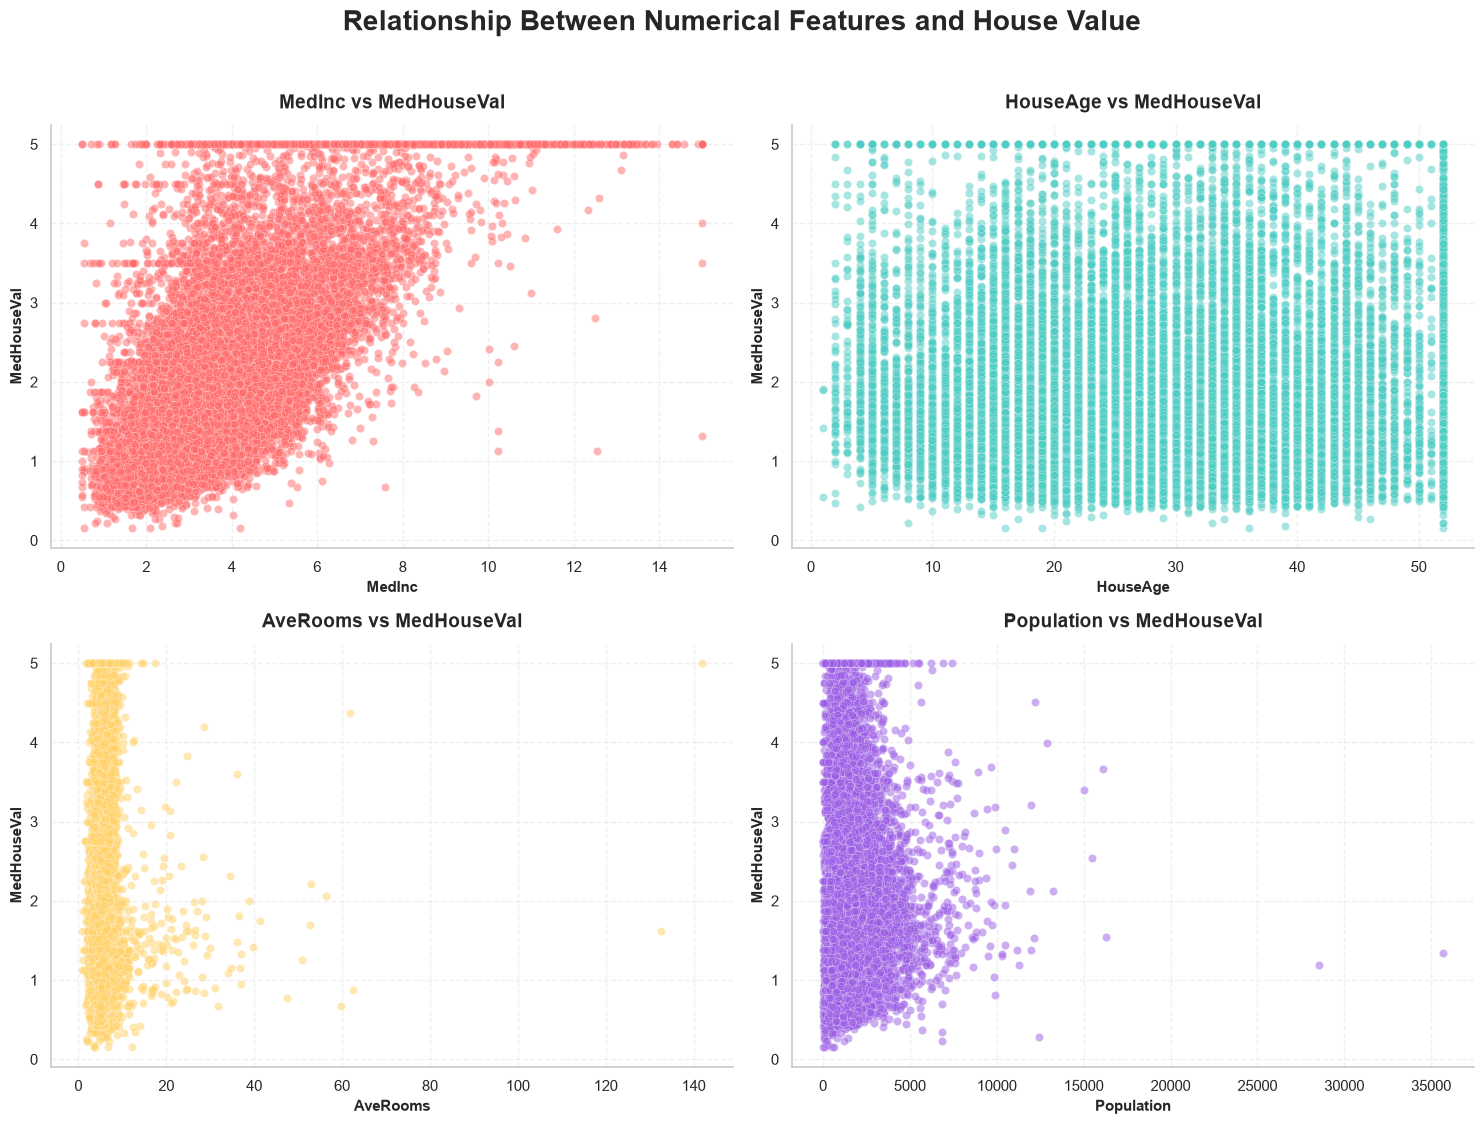

In [10]:


# Attractive color palette
colors = [
    "#FF6B6B",  # Coral Red
    "#4ECDC4",  # Turquoise
    "#FFD166",  # Golden Yellow
    "#9B5DE5"   # Purple
]

# Scatter plot columns
scatter_columns = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "Population"
]

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Flatten axes for easier looping
axes = axes.flatten()

for i, column in enumerate(scatter_columns):

    sns.scatterplot(
        data=df,
        x=column,
        y="MedHouseVal",
        color=colors[i],
        alpha=0.5,
        s=35,
        edgecolor="white",
        linewidth=0.3,
        ax=axes[i]
    )

    # Title
    axes[i].set_title(
        f"{column} vs MedHouseVal",
        fontsize=14,
        fontweight="bold",
        pad=12
    )

    # Labels
    axes[i].set_xlabel(
        column,
        fontsize=11,
        fontweight="bold"
    )

    axes[i].set_ylabel(
        "MedHouseVal",
        fontsize=11,
        fontweight="bold"
    )

    # Grid
    axes[i].grid(
        linestyle="--",
        alpha=0.3
    )

    # Remove unnecessary borders
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

# Main title
fig.suptitle(
    "Relationship Between Numerical Features and House Value",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

# Save high-quality image
plt.savefig(
    "images/scatter_plots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The scatter plots showed that MedInc has the clearest visible positive relationship with MedHouseVal, where areas with higher median income generally tend to have higher house values.
The relationship between HouseAge and house value appeared weaker, with substantial variation in house values across different age groups. 
The AveRooms and Population plots showed that most observations were concentrated within lower ranges, while a small number of observations extended to very high values, supporting the earlier findings of high positive skewness and potential outliers

### Correlation Matrix

Correlation measures the linear relationship between two variables.

Measures linear relationship and scatter plots shows patterns and spread

In [11]:
# Correlation matrix

correlation_matrix = df[numerical_columns].corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)


Correlation Matrix:
               MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc       1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge    -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms     0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms   -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population   0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup     0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
Latitude    -0.079809  0.011173  0.106389   0.069721   -0.108785  0.002366   
Longitude   -0.015176 -0.108197 -0.027540   0.013344    0.099773  0.002476   
MedHouseVal  0.688075  0.105623  0.151948  -0.046701   -0.024650 -0.023737   

             Latitude  Longitude  MedHouseVal  
MedInc      -0.079809  -0.015176     0.688075  
HouseAge     0.011173  -0.108197     0.105623  
AveRooms     0.106389  -0.027540     0.151948  
AveBed


## Correlation Heatmap

visualize the correlation matrix.


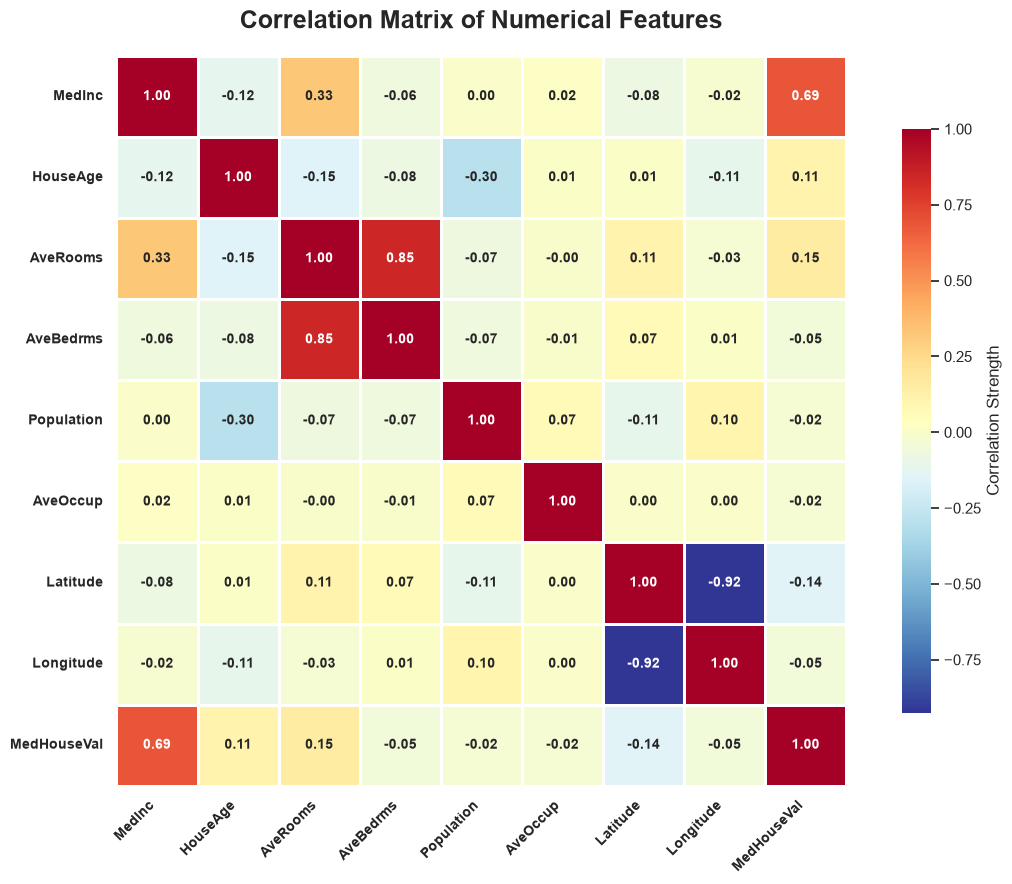

In [12]:
# Correlation Heatmap

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",        #  red-yellow-blue gradient
    linewidths=1,
    linecolor="white",
    square=True,
    cbar_kws={
        "shrink": 0.8,
        "label": "Correlation Strength"
    },
    annot_kws={
        "size": 10,
        "weight": "bold"
    }
)

plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xticks(
    rotation=45,
    ha="right",
    fontsize=10,
    fontweight="bold"
)

plt.yticks(
    rotation=0,
    fontsize=10,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The correlation matrix showed that MedInc had the strongest positive linear relationship with the target variable, MedHouseVal, with a correlation coefficient of approximately 0.69.
This suggests that higher median income is generally associated with higher median house values. 
The analysis also revealed a strong positive correlation between AveRooms and AveBedrms (0.85) and a strong negative correlation between Latitude and Longitude (-0.92). 
These strong relationships between predictor variables may indicate potential multicollinearity, which will be examined later using Variance Inflation Factor (VIF). Most of the remaining variables showed relatively weak linear correlations with MedHouseVal.

### Boxplot

It helps us visualize:
Median,Quartiles,IQR,Potential outliers.


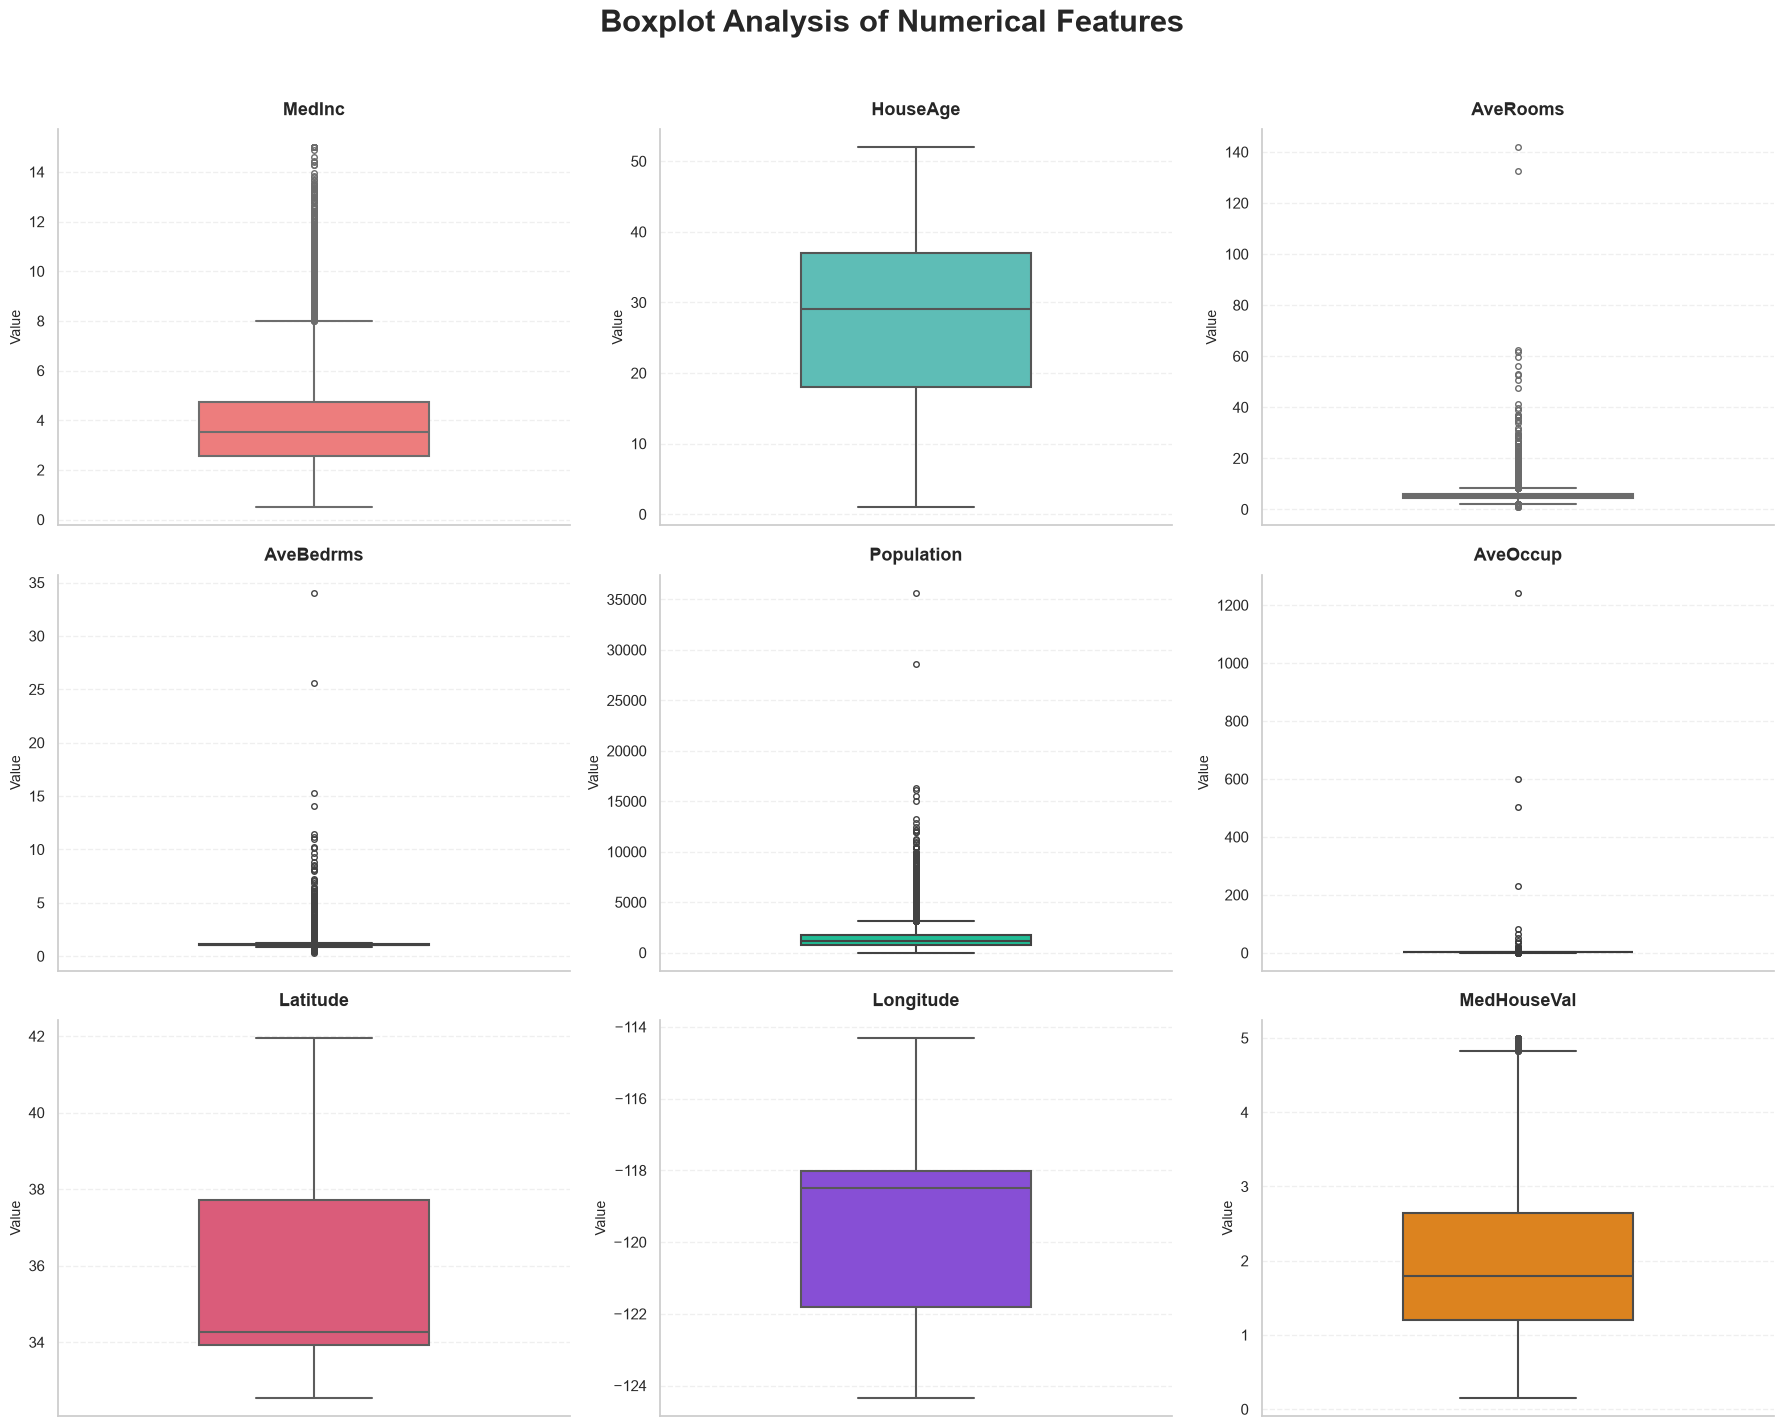

In [13]:
#Boxplot
colors = [
    "#FF6B6B",  # Coral Red
    "#4ECDC4",  # Turquoise
    "#FFD166",  # Yellow
    "#6A4C93",  # Purple
    "#06D6A0",  # Green
    "#118AB2",  # Blue
    "#EF476F",  # Pink
    "#8338EC",  # Violet
    "#FB8500"   # Orange
]

# Create figure
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(18, 14)
)

axes = axes.flatten()

# Create boxplot for each numerical variable
for i, column in enumerate(numerical_columns):

    sns.boxplot(
        y=df[column],
        ax=axes[i],
        color=colors[i % len(colors)],
        width=0.45,
        linewidth=1.5,
        fliersize=4
    )

    # Title
    axes[i].set_title(
        column,
        fontsize=13,
        fontweight="bold",
        pad=10
    )

    # Axis labels
    axes[i].set_xlabel("")
    axes[i].set_ylabel(
        "Value",
        fontsize=10
    )

    # Subtle grid
    axes[i].grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    # Clean borders
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Main title
fig.suptitle(
    "Boxplot Analysis of Numerical Features",
    fontsize=22,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

# Save high-quality image
plt.savefig(
    "images/boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Boxplots were generated to examine the distribution and potential outliers in the numerical variables. 

HouseAge, Latitude, and Longitude showed relatively limited evidence of extreme observations compared with the other variables. 

In contrast, MedInc, AveRooms, AveBedrms, Population, and particularly AveOccup showed observations beyond their upper whiskers. The presence of extreme values is consistent with the high positive skewness and kurtosis observed in the descriptive statistics. 

AveOccup exhibited the most extreme distribution, with a small number of observations substantially higher than the majority of the data. 

The target variable MedHouseVal also showed a concentration at its upper limit of 5, indicating a ceiling effect.

#### outliers summary

In [14]:
outlier_summary = []

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        "Variable": column,
        "Outlier Count": len(outliers),
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound
    })

outlier_df = pd.DataFrame(outlier_summary)

print("\nOutlier Summary:")
print(outlier_df)


Outlier Summary:
      Variable  Outlier Count  Lower Bound  Upper Bound
0       MedInc            681    -0.706375     8.013025
1     HouseAge              0   -10.500000    65.500000
2     AveRooms            511     2.023219     8.469878
3    AveBedrms           1424     0.865909     1.239697
4   Population           1196  -620.000000  3132.000000
5     AveOccup            711     1.150961     4.561041
6     Latitude              0    28.260000    43.380000
7    Longitude              0  -127.485000  -112.325000
8  MedHouseVal           1071    -0.980875     4.824125


The analysis showed that HouseAge, Latitude, and Longitude had no IQR-based potential outliers. In contrast, AveRooms, AveBedrms, Population, and AveOccup contained a considerable number of potential outliers. This finding is consistent with their high positive skewness observed during descriptive analysis.

MedHouseVal also contained 1,071 observations above the calculated upper IQR boundary. However, the scatter plots and boxplot showed that the target variable is concentrated at its upper limit of 5. 

The identified potential outliers were retained for further analysis because the IQR method identifies unusual observations but does not establish that those observations are erroneous.

### Hypothesis Testing

Hypothesis Test 1: Low Income vs High Income using target numerical variable MedHouseVal .

In [15]:
# HYPOTHESIS TEST 1
# Low Income vs High Income


low_income = df.loc[
    df["IncomeGroup"] == "Low",
    "MedHouseVal"
]

high_income = df.loc[
    df["IncomeGroup"] == "High",
    "MedHouseVal"
]

print("\nLow Income Group:")
print(low_income.describe())

print("\nHigh Income Group:")
print(high_income.describe())


Low Income Group:
count    6880.000000
mean        1.312554
std         0.731091
min         0.149990
25%         0.806000
50%         1.125000
75%         1.625000
max         5.000010
Name: MedHouseVal, dtype: float64

High Income Group:
count    6879.000000
mean        2.953179
std         1.133155
min         0.475000
25%         2.082500
50%         2.715000
75%         3.685500
max         5.000010
Name: MedHouseVal, dtype: float64


The MedHouseVal variable was separated into low-income and high-income groups using the IncomeGroup categorical variable. 
The low-income group contained 6,880 observations, while the high-income group contained 6,879 observations. 
The mean median house value was 1.313 for the low-income group and 2.953 for the high-income group.
Similarly, the median values were 1.125 and 2.715, respectively.
This indicates a substantial descriptive difference in house values between the two groups.

In [16]:
from scipy.stats import shapiro

low_sample = low_income.sample(
    n=5000,
    random_state=42
)

high_sample = high_income.sample(
    n=5000,
    random_state=42
)

shapiro_low = shapiro(low_sample)
shapiro_high = shapiro(high_sample)

print("\nShapiro-Wilk Test")

print("Low Income:")
print("Statistic:", shapiro_low.statistic)
print("p-value:", shapiro_low.pvalue)

print("\nHigh Income:")
print("Statistic:", shapiro_high.statistic)
print("p-value:", shapiro_high.pvalue)


Shapiro-Wilk Test
Low Income:
Statistic: 0.8491112224861762
p-value: 2.1998671591483326e-56

High Income:
Statistic: 0.9339957816281814
p-value: 1.7784826290082675e-42


Null hypothesis H0​ ->                 H0​:The data is normally distributed

Alternative hypothesis H1->       H1​:The data is not normally distributed 


#### Compare p-value with 0.05:

Low Income 
2.20×10^{−56}<0.05

Therefore:

Reject (H0).

So the Low Income group's MedHouseVal does not satisfy the normality assumption.

High Income 
1.78×10^{−42}<0.05

Therefore:

Reject (H0).

So the High Income group's MedHouseVal also does not satisfy the normality assumption.

Therefore

Both groups have extremely small p-values:

Low Income   → p < 0.05 → Not normal
High Income  → p < 0.05 → Not normal

So, we should use Mann-Whitney U Test
	​


#### Levene's Test

In [17]:
from scipy.stats import levene

levene_result = levene(
    low_income,
    high_income
)

print("\nLevene's Test")
print("Statistic:", levene_result.statistic)
print("p-value:", levene_result.pvalue)


Levene's Test
Statistic: 1472.767341730319
p-value: 3.307748633014862e-306
